# Phân tích Khám phá Dữ liệu GLDAS-Noah (2019-2024) cho Đồng bằng sông Cửu Long

Notebook này xây dựng phân tích EDA chi tiết theo yêu cầu luận văn: khám phá 38 biến khí tượng - thủy văn GLDAS-Noah nhằm phục vụ bài toán dự đoán năng suất lúa cho 13 tỉnh/thành ĐBSCL (2019-2024).

## Mục tiêu chính
- Hiểu rõ **động lực nước** (độ ẩm đất, bốc hơi, mưa) và ảnh hưởng đến stress cây lúa.
- Đo lường **nhiệt năng** (bức xạ, nhiệt độ) và tác động lên chu trình sinh trưởng.
- So sánh khác biệt giữa các tỉnh, phát hiện vùng có rủi ro hạn, ngập hoặc xâm nhập mặn.
- Nhận diện xu hướng, tính thời vụ và các điểm bất thường làm đầu mối cho gắn nhãn sự kiện cực đoan.
- Chuẩn bị tập đặc trưng cho mô hình deep learning không gian-thời gian.

## Cấu trúc notebook
1. Thiết lập môi trường & tải dữ liệu
2. Metadata & kiểm tra chất lượng
3. Phân tích đơn biến (theo nhóm biến chức năng)
4. Phân tích song biến (quan hệ nước - năng lượng - nhiệt)
5. Phân tích đa biến (PCA, phân cụm tỉnh)
6. Chuỗi thời gian chuyên sâu (STL, bất thường)
7. Tổng kết insight & gợi ý cho mô hình dự đoán

In [ ]:
import warnings

warnings.filterwarnings("ignore")


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

print("✓ Đã import thư viện phân tích")


✓ Đã import thư viện phân tích


## 1. Thiết lập đường dẫn & tải dữ liệu

In [ ]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "dataset" / "natural" / "gldas"
OUTPUT_DIR = BASE_DIR / "output" / "gldas_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gldas_path = DATA_DIR / "gldas_mekong_delta_2019_2024_full.csv"
metadata_path = DATA_DIR / "metadata.json"


In [ ]:
df_gldas = pd.read_csv(gldas_path)
print("Kích thước ban đầu:", df_gldas.shape)
df_gldas.head()


Kích thước ban đầu: (28496, 38)


,province,date,Albedo_inst,AvgSurfT_inst,CanopInt_inst,ECanop_tavg,ESoil_tavg,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,PotEvap_tavg,Psurf_f_inst,Qair_f_inst,Qg_tavg,Qh_tavg,Qle_tavg,Qs_acc,Qsb_acc,Qsm_acc,Rainf_f_tavg,Rainf_tavg,RootMoist_inst,SWE_inst,SWdown_f_tavg,SnowDepth_inst,Snowf_tavg,SoilMoi0_10cm_inst,SoilMoi100_200cm_inst,SoilMoi10_40cm_inst,SoilMoi40_100cm_inst,SoilTMP0_10cm_inst,SoilTMP100_200cm_inst,SoilTMP10_40cm_inst,SoilTMP40_100cm_inst,Swnet_tavg,Tair_f_inst,Tveg_tavg,Wind_f_inst
0,Soc Trang,2019-01-01,15.064176,296.116210,0.257861,31.123575,48.354889,0.000043,422.840910,-12.606521,173.764457,101232.818659,0.014151,-10.418176,-38.104070,108.569960,0.032133,0.036092,0,0.000100,0.000100,481.238957,0,84.888216,0,0,36.618508,376.820023,109.483582,222.052965,296.988799,299.784654,298.973396,299.460783,72.072214,297.177087,29.091923,4.949059
1,Soc Trang,2019-01-02,15.046503,295.184524,0.499870,55.129715,48.429627,0.000041,415.283950,-14.500901,124.360464,101106.910015,0.015377,-8.107116,-23.509368,103.560059,0.386398,0.038521,0,0.000440,0.000440,502.086941,0,100.574609,0,0,41.005633,378.098621,119.739326,227.769187,295.883946,299.772967,298.485258,299.381557,85.444306,295.725244,0.000202,6.319528
2,Soc Trang,2019-01-03,15.032153,297.402127,0.492814,66.882153,61.510069,0.000051,406.891451,-34.385217,154.212436,101182.278360,0.017425,1.642598,-40.423592,128.317486,0.081100,0.058499,0,0.000187,0.000187,516.648475,0,145.314709,0,0,40.363456,385.877021,121.098372,238.944090,297.146986,299.756565,298.251014,299.262356,123.494097,298.230100,0.183332,6.701585
3,Soc Trang,2019-01-04,15.017210,298.247638,0.272502,52.087458,71.429661,0.000059,396.353801,-50.506378,195.024455,101292.914785,0.017922,-0.018324,-45.764895,147.013510,0.052008,0.095291,0,0.000094,0.000094,516.697481,0,178.068003,0,0,39.405508,395.187514,119.247282,239.034454,298.235860,299.735344,298.403681,299.168705,151.358240,299.458283,25.144652,6.677373
4,Soc Trang,2019-01-05,14.999537,298.353805,0.046923,10.364185,71.103222,0.000057,374.329173,-72.841701,219.990448,101285.632784,0.017401,-1.502093,-9.859060,142.058437,0.000000,0.122508,0,0.000003,0.000003,508.409366,0,239.398918,0,0,37.615569,400.329959,115.131874,235.381042,298.508252,299.711972,298.590338,299.120141,203.494508,299.504699,64.742871,5.563865


In [ ]:
with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("=" * 90)
print("DANH MỤC BIẾN GLDAS (mô tả & đơn vị)")
print("=" * 90)
for var, info in metadata.items():
    print(
        f"{var:>22}: {info.get('description', 'N/A')} | Đơn vị: {info.get('unit', 'N/A')}"
    )


DANH MỤC BIẾN GLDAS (mô tả & đơn vị)
           Albedo_inst: Độ phản xạ bề mặt (Albedo) tức thời. Giá trị trung bình hàng ngày. | Đơn vị: dimensionless (0-1)
         AvgSurfT_inst: Nhiệt độ bề mặt trung bình (Average Surface Temperature) tức thời. Giá trị trung bình hàng ngày. | Đơn vị: K
         CanopInt_inst: Lượng nước tích trữ trong tán cây (Canopy Water Content) tức thời. Giá trị trung bình hàng ngày. | Đơn vị: kg/m2
           ECanop_tavg: Thông lượng nhiệt ẩn (Latent Heat Flux) bốc hơi từ tán cây (Canopy Evaporation), trung bình 3 giờ. Giá trị trung bình hàng ngày. | Đơn vị: W/m2
            ESoil_tavg: Thông lượng nhiệt ẩn (Latent Heat Flux) bốc hơi từ đất trần (Soil Evaporation), trung bình 3 giờ. Giá trị trung bình hàng ngày. | Đơn vị: W/m2
             Evap_tavg: Tốc độ bốc hơi tổng cộng (Total Evaporation Flux), trung bình 3 giờ. Giá trị trung bình hàng ngày. | Đơn vị: kg/m2/s
         LWdown_f_tavg: Bức xạ sóng dài đi xuống (Longwave Radiation Downward) tới bề mặt, trung

## 2. Tiền xử lý & kiểm tra chất lượng dữ liệu
- Chuẩn hóa `date` sang datetime
- Ép toàn bộ biến về số thực (có thể xuất hiện giá trị thiếu do ép dữ liệu)
- Loại bỏ bản ghi trùng, tạo MultiIndex (`date`, `province`)
- Thống kê sơ bộ về phạm vi thời gian và danh sách tỉnh

In [ ]:
df_gldas["date"] = pd.to_datetime(df_gldas["date"])
numeric_cols = df_gldas.columns.difference(["date", "province"])
df_gldas[numeric_cols] = df_gldas[numeric_cols].apply(pd.to_numeric, errors="coerce")

duplicate_count = df_gldas.duplicated(subset=["date", "province"]).sum()
if duplicate_count:
    df_gldas = df_gldas.drop_duplicates(subset=["date", "province"])

df_gldas.set_index(["date", "province"], inplace=True)
df_gldas.sort_index(inplace=True)

print(
    f"Khoảng thời gian: {df_gldas.index.get_level_values('date').min()} → {df_gldas.index.get_level_values('date').max()}"
)
print(f"Số tỉnh: {df_gldas.index.get_level_values('province').nunique()}")
print(f"Số bản ghi: {len(df_gldas):,}")
print(f"Số bản ghi trùng đã loại bỏ: {duplicate_count}")


Khoảng thời gian: 2019-01-01 00:00:00 → 2024-12-31 00:00:00
Số tỉnh: 13
Số bản ghi: 28,496
Số bản ghi trùng đã loại bỏ: 0


In [ ]:
print("Danh sách tỉnh:", sorted(df_gldas.index.get_level_values("province").unique()))
print("Tổng số biến khí tượng-thủy văn:", len(numeric_cols))


Danh sách tỉnh: ['An Giang', 'Bac Lieu', 'Ben Tre', 'Ca Mau', 'Can Tho city', 'Dong Thap', 'Hau Giang', 'Kien Giang', 'Long An', 'Soc Trang', 'Tien Giang', 'Tra Vinh', 'Vinh Long']
Tổng số biến khí tượng-thủy văn: 36


### Giá trị thiếu & nội suy
Kiểm tra tỷ lệ thiếu và nội suy theo thời gian cho từng tỉnh (phục vụ mô hình chuỗi).

In [ ]:
missing_values = df_gldas.isna().sum().sort_values(ascending=False)
missing_pct = (missing_values / len(df_gldas)) * 100
missing_df = pd.DataFrame({"Số lượng thiếu": missing_values, "Tỷ lệ (%)": missing_pct})
missing_df.head(15)


,Số lượng thiếu,Tỷ lệ (%)
Albedo_inst,0,0.0
AvgSurfT_inst,0,0.0
CanopInt_inst,0,0.0
ECanop_tavg,0,0.0
ESoil_tavg,0,0.0
Evap_tavg,0,0.0
LWdown_f_tavg,0,0.0
Lwnet_tavg,0,0.0
PotEvap_tavg,0,0.0
Psurf_f_inst,0,0.0


In [ ]:
if missing_values.sum() > 0:
    df_gldas = (
        df_gldas.groupby("province")
        .apply(lambda g: g.interpolate(method="time"))
        .droplevel(0)
    )
    df_gldas = (
        df_gldas.groupby("province")
        .apply(lambda g: g.fillna(method="bfill").fillna(method="ffill"))
        .droplevel(0)
    )
    print("✓ Đã nội suy và lấp đầy giá trị thiếu theo thời gian cho từng tỉnh")
else:
    print("✓ Dữ liệu không có giá trị thiếu")


✓ Dữ liệu không có giá trị thiếu


## 3. Phân tích đơn biến
Tập trung vào 4 nhóm biến quan trọng: độ ẩm đất, nhiệt độ, bức xạ & năng lượng, bốc hơi & thủy văn.

In [ ]:
summary_stats = df_gldas.describe().T
summary_stats["range"] = summary_stats["max"] - summary_stats["min"]
summary_stats[["mean", "std", "min", "max", "range"]].sort_values(
    "range", ascending=False
).head(20).round(3)


,mean,std,min,max,range
Psurf_f_inst,100902.726,204.677,100114.335,101575.428,1461.094
RootMoist_inst,439.581,113.153,129.170,729.106,599.936
PotEvap_tavg,223.431,69.292,41.897,489.392,447.495
SWdown_f_tavg,207.236,50.663,38.405,305.723,267.319
Qle_tavg,106.572,38.746,9.400,249.374,239.974
Qh_tavg,21.261,38.126,-98.330,141.507,239.837
SoilMoi100_200cm_inst,372.333,47.690,235.505,467.005,231.500
Swnet_tavg,176.934,43.216,32.793,262.603,229.810
SoilMoi40_100cm_inst,199.078,47.644,68.269,266.142,197.873
ESoil_tavg,49.750,28.711,0.439,163.171,162.732


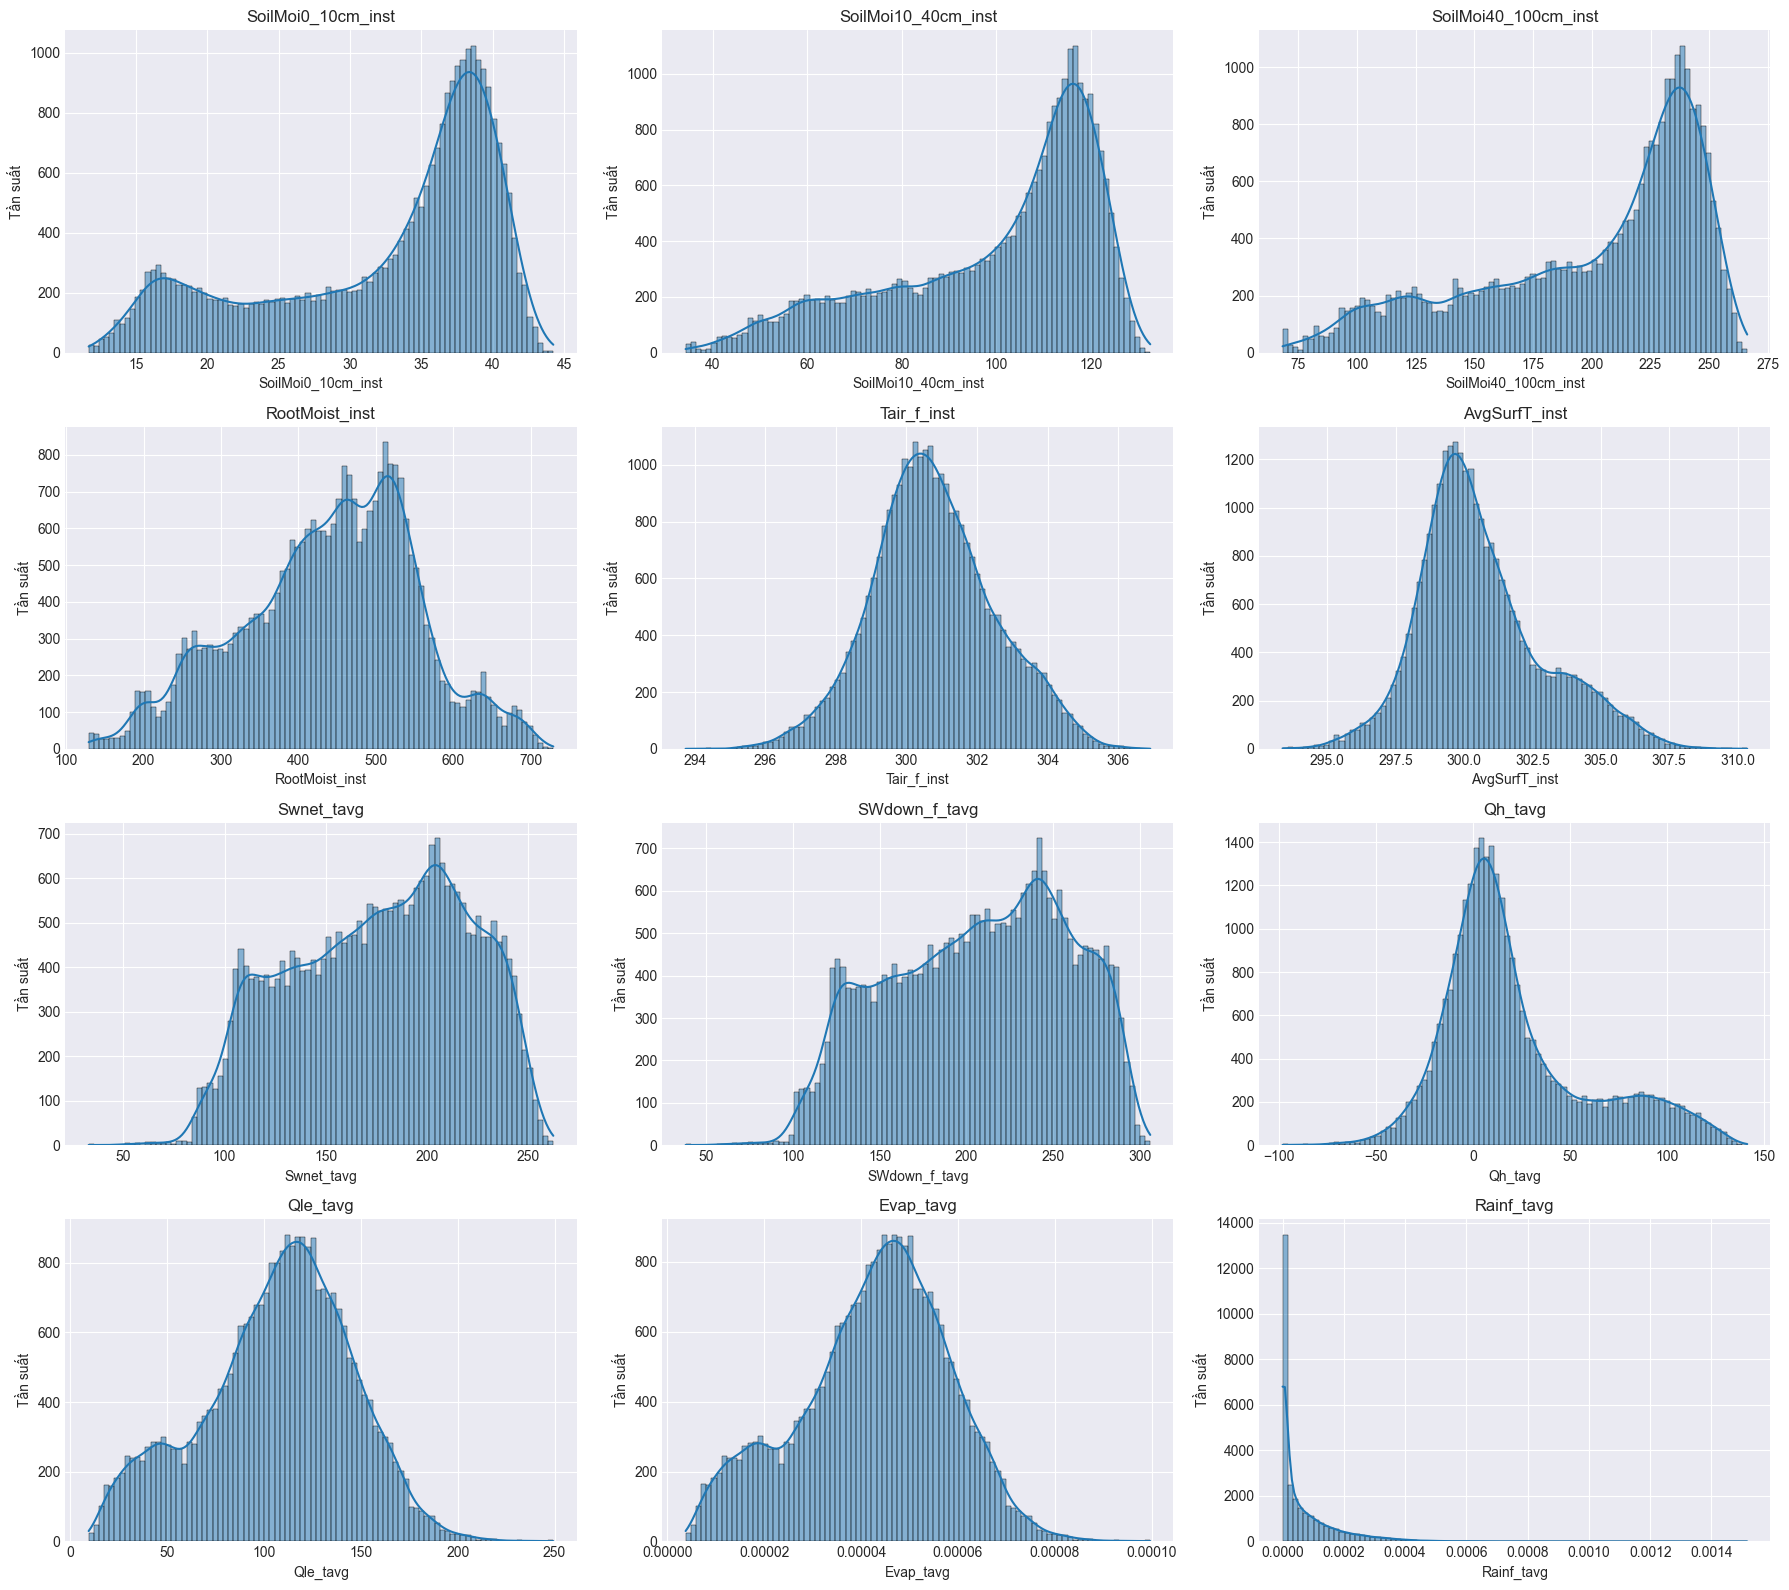

In [ ]:
selected_vars = [
    "SoilMoi0_10cm_inst",
    "SoilMoi10_40cm_inst",
    "SoilMoi40_100cm_inst",
    "RootMoist_inst",
    "Tair_f_inst",
    "AvgSurfT_inst",
    "Swnet_tavg",
    "SWdown_f_tavg",
    "Qh_tavg",
    "Qle_tavg",
    "Evap_tavg",
    "Rainf_tavg",
]
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for ax, var in zip(axes.flat, selected_vars):
    sns.histplot(
        data=df_gldas.reset_index(), x=var, kde=True, ax=ax, bins=90, color="#1f77b4"
    )
    ax.set_title(var)
    ax.set_ylabel("Tần suất")
plt.tight_layout()
plt.show()


In [ ]:
monthly_mean = df_gldas.groupby(pd.Grouper(level="date", freq="M")).mean()
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=["SoilMoi0_10cm_inst", "Tair_f_inst", "Swnet_tavg", "Evap_tavg"],
    shared_xaxes=True,
)
fig.add_trace(
    go.Scatter(
        x=monthly_mean.index,
        y=monthly_mean["SoilMoi0_10cm_inst"],
        mode="lines",
        name="SoilMoi0-10cm",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=monthly_mean.index, y=monthly_mean["Tair_f_inst"], mode="lines", name="Tair"
    ),
    row=1,
    col=2,
)
fig.add_trace(
    go.Scatter(
        x=monthly_mean.index, y=monthly_mean["Swnet_tavg"], mode="lines", name="Swnet"
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=monthly_mean.index, y=monthly_mean["Evap_tavg"], mode="lines", name="Evap"
    ),
    row=2,
    col=2,
)
fig.update_layout(height=700, title="Xu hướng trung bình tháng (toàn vùng)")
fig.show()


## 4. Phân tích song biến
Khảo sát mối quan hệ giữa độ ẩm đất, bốc hơi, bức xạ và nhiệt độ.

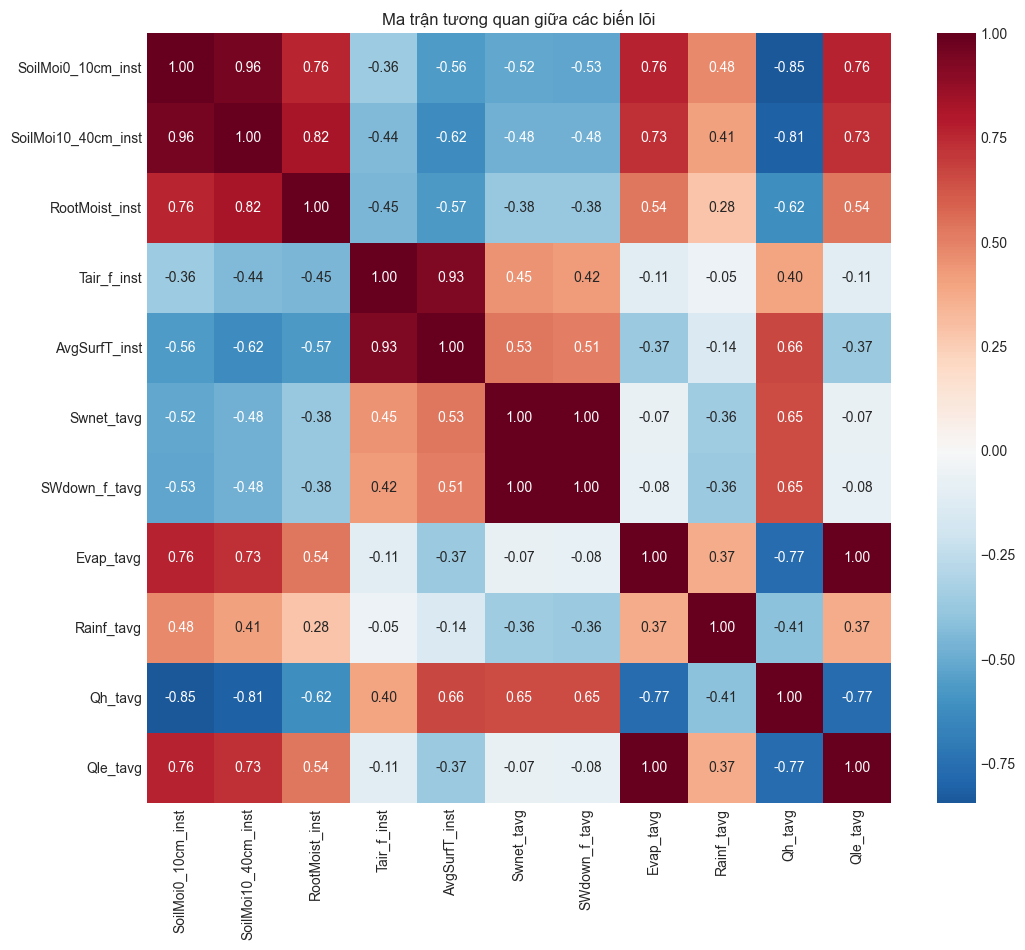

In [ ]:
corr_subset = df_gldas[
    [
        "SoilMoi0_10cm_inst",
        "SoilMoi10_40cm_inst",
        "RootMoist_inst",
        "Tair_f_inst",
        "AvgSurfT_inst",
        "Swnet_tavg",
        "SWdown_f_tavg",
        "Evap_tavg",
        "Rainf_tavg",
        "Qh_tavg",
        "Qle_tavg",
    ]
].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Ma trận tương quan giữa các biến lõi")
plt.show()


In [ ]:
pair_df = df_gldas.reset_index()
pair_sample = pair_df.sample(min(6000, len(pair_df)), random_state=42)
fig = px.scatter_matrix(
    pair_sample,
    dimensions=[
        "SoilMoi0_10cm_inst",
        "RootMoist_inst",
        "Evap_tavg",
        "Swnet_tavg",
        "Tair_f_inst",
    ],
    color="province",
    opacity=0.5,
    title="Scatter matrix: tương tác nước - năng lượng - nhiệt",
)
fig.update_traces(diagonal_visible=True)
fig.show()


In [ ]:
prov_month = (
    df_gldas.groupby([pd.Grouper(level="date", freq="M"), "province"])
    .agg(
        {
            "SoilMoi0_10cm_inst": "mean",
            "Evap_tavg": "mean",
            "Swnet_tavg": "mean",
            "Rainf_tavg": "sum",
        }
    )
    .reset_index()
)
fig = px.scatter(
    prov_month,
    x="Swnet_tavg",
    y="Evap_tavg",
    color="province",
    size="Rainf_tavg",
    hover_data=["province", "date"],
    trendline="ols",
    title="Bức xạ ròng vs Bốc hơi theo tỉnh (bubble = lượng mưa tháng)",
)
fig.show()


In [ ]:
province_profile = (
    df_gldas.groupby("province")
    .agg(
        {
            "SoilMoi0_10cm_inst": "mean",
            "RootMoist_inst": "mean",
            "Evap_tavg": "mean",
            "Rainf_tavg": "sum",
            "Tair_f_inst": "mean",
            "Swnet_tavg": "mean",
        }
    )
    .sort_values("SoilMoi0_10cm_inst", ascending=False)
)
display(province_profile.round(3))
fig = px.bar(
    province_profile.reset_index(),
    x="province",
    y=["SoilMoi0_10cm_inst", "RootMoist_inst", "Evap_tavg", "Swnet_tavg"],
    barmode="group",
    title="So sánh trung bình theo tỉnh (độ ẩm - bốc hơi - bức xạ)",
)
fig.show()


,SoilMoi0_10cm_inst,RootMoist_inst,Evap_tavg,Rainf_tavg,Tair_f_inst,Swnet_tavg
province,,,,,,
Hau Giang,34.377,457.916,0.0,0.144,300.676,172.118
Can Tho city,34.314,380.234,0.0,0.152,300.719,175.982
Bac Lieu,33.402,484.688,0.0,0.143,300.857,172.782
Tien Giang,33.168,468.657,0.0,0.155,300.517,179.210
Kien Giang,33.077,450.316,0.0,0.151,300.866,174.626
An Giang,32.595,372.644,0.0,0.157,301.022,180.602
Ben Tre,31.996,558.244,0.0,0.146,300.472,176.348
Soc Trang,31.841,441.133,0.0,0.137,300.774,173.791
Long An,31.542,424.553,0.0,0.157,300.964,184.446


## 5. Phân tích đa biến & phân cụm tỉnh
Sử dụng PCA để giảm chiều và KMeans để phân nhóm tỉnh có hành vi khí hậu tương đồng.

In [ ]:
province_features = df_gldas.groupby("province").mean()
scaler = StandardScaler()
scaled_feat = scaler.fit_transform(province_features)
pca = PCA(n_components=5, random_state=42)
pca_components = pca.fit_transform(scaled_feat)
explained = pca.explained_variance_ratio_
fig = go.Figure()
fig.add_trace(go.Bar(x=[f"PC{i+1}" for i in range(len(explained))], y=explained * 100))
fig.update_layout(title="Phương sai giải thích bởi PCA", yaxis_title="% Variance")
fig.show()


In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(pca_components)
province_cluster_df = pd.DataFrame(
    {"province": province_features.index, "cluster": clusters}
)
fig = px.scatter(
    x=pca_components[:, 0],
    y=pca_components[:, 1],
    color=clusters.astype(str),
    text=province_features.index,
    title="Phân cụm tỉnh trong không gian PCA (PC1 vs PC2)",
)
fig.update_traces(textposition="top center")
fig.update_layout(
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
)
fig.show()
province_cluster_df


,province,cluster
0,An Giang,2
1,Bac Lieu,1
2,Ben Tre,0
3,Ca Mau,1
4,Can Tho city,0
5,Dong Thap,2
6,Hau Giang,0
7,Kien Giang,1
8,Long An,2
9,Soc Trang,1


### Tương quan giữa các tỉnh dựa trên độ ẩm đất (0-10cm)

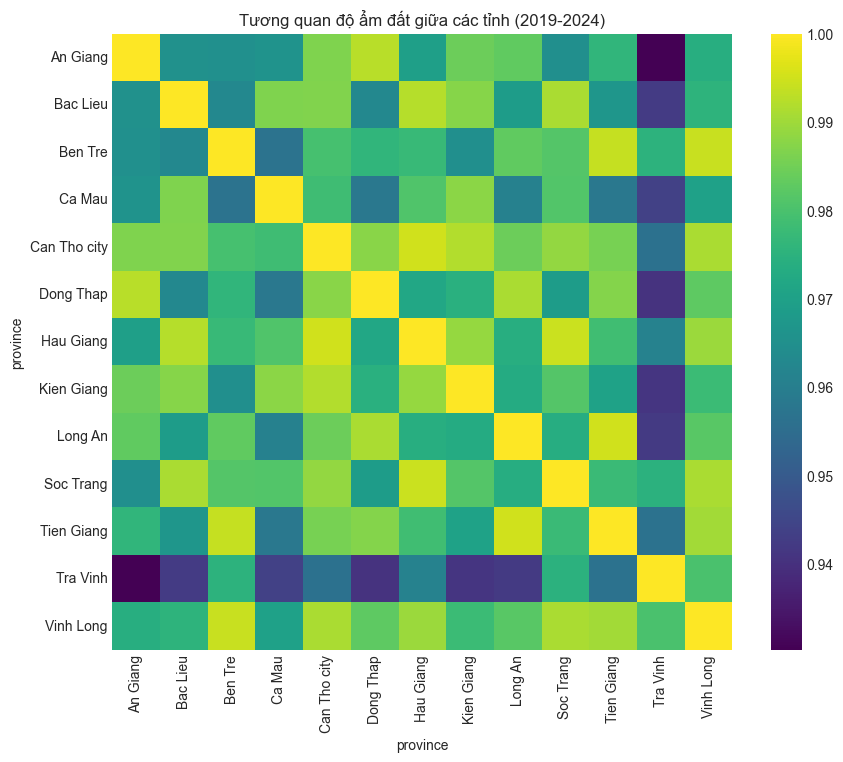

In [ ]:
pivot_daily = df_gldas.reset_index().pivot(
    index="date", columns="province", values="SoilMoi0_10cm_inst"
)
pivot_daily = pivot_daily.interpolate().fillna(method="bfill").fillna(method="ffill")
corr_province = pivot_daily.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_province, annot=False, cmap="viridis")
plt.title("Tương quan độ ẩm đất giữa các tỉnh (2019-2024)")
plt.show()


## 6. Chuỗi thời gian chuyên sâu & phát hiện bất thường
Phân rã STL để bóc tách xu hướng - thời vụ - phần dư cho độ ẩm đất lớp 0-10cm tại một tỉnh tiêu biểu.

In [ ]:
province_focus = "An Giang"
ts_soil = df_gldas.loc[(slice(None), province_focus), "SoilMoi0_10cm_inst"].droplevel(
    "province"
)
ts_soil = ts_soil.asfreq("D").interpolate()
stl = STL(ts_soil, period=365, robust=True)
stl_result = stl.fit()
fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Observed", "Trend", "Seasonal", "Residual"],
)
fig.add_trace(
    go.Scatter(x=stl_result.observed.index, y=stl_result.observed, name="Observed"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=stl_result.trend.index, y=stl_result.trend, name="Trend"), row=2, col=1
)
fig.add_trace(
    go.Scatter(x=stl_result.seasonal.index, y=stl_result.seasonal, name="Seasonal"),
    row=3,
    col=1,
)
fig.add_trace(
    go.Scatter(x=stl_result.resid.index, y=stl_result.resid, name="Residual"),
    row=4,
    col=1,
)
fig.update_layout(height=900, title=f"Phân rã STL độ ẩm đất 0-10cm - {province_focus}")
fig.show()


In [ ]:
residual = stl_result.resid
sigma = residual.std()
threshold = 2.5
anomalies = residual[np.abs(residual) > threshold * sigma]
print(f"Số ngày bất thường (|residual| > {threshold}σ): {len(anomalies)}")
if not anomalies.empty:
    display(anomalies.sort_values(key=np.abs, ascending=False).head(10))
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=ts_soil.index, y=ts_soil, mode="lines", name="Soil Moisture")
)
fig.add_trace(
    go.Scatter(
        x=anomalies.index,
        y=ts_soil.loc[anomalies.index],
        mode="markers",
        marker=dict(color="red", size=9, symbol="x"),
        name="Anomaly",
    )
)
fig.update_layout(
    title="Các ngày độ ẩm đất bất thường", xaxis_title="Ngày", yaxis_title="m³/m³"
)
fig.show()


Số ngày bất thường (|residual| > 2.5σ): 117


date
2022-03-28    19.958012
2022-03-23    18.677549
2022-03-22    17.180606
2022-03-29    17.073117
2022-05-02    17.013553
2022-03-30    16.525123
2024-04-15   -16.492608
2022-03-19    16.382946
2022-04-01    16.315298
2022-03-24    16.205850
Name: resid, dtype: float64

## 7. Liên hệ biến quan trọng với độ ẩm vùng rễ
Độ ẩm vùng rễ (`RootMoist_inst`) là biến trọng yếu phản ánh sức khỏe đồng ruộng. Tính tương quan để lựa chọn đặc trưng cho mô hình dự đoán năng suất.

In [ ]:
root_corr = df_gldas.corr(numeric_only=True)["RootMoist_inst"].sort_values(
    ascending=False
)
root_corr.head(15)


RootMoist_inst           1.000000
SoilMoi40_100cm_inst     0.851269
SoilMoi10_40cm_inst      0.823604
SoilMoi0_10cm_inst       0.755179
SoilMoi100_200cm_inst    0.662604
Lwnet_tavg               0.548841
Qsb_acc                  0.543337
Evap_tavg                0.538563
Qle_tavg                 0.538563
ESoil_tavg               0.536185
CanopInt_inst            0.419773
Qair_f_inst              0.411613
ECanop_tavg              0.376445
Rainf_f_tavg             0.283011
Rainf_tavg               0.283011
Name: RootMoist_inst, dtype: float64

In [ ]:
fig = px.bar(
    root_corr.head(20).iloc[1:],
    x=root_corr.head(20).iloc[1:].index,
    y=root_corr.head(20).iloc[1:].values,
    title="Top biến tương quan dương với RootMoist_inst",
)
fig.update_layout(
    xaxis_title="Biến", yaxis_title="Hệ số tương quan", xaxis_tickangle=-45
)
fig.show()


## 8. Insight & lựa chọn đặc trưng quan trọng
- **Cân bằng nước trong đất (GLDAS)**: Các histogram và đường xu hướng tháng cho thấy `SoilMoi0_10cm_inst`, `SoilMoi10_40cm_inst`, `SoilMoi40_100cm_inst` và `RootMoist_inst` biến động mạnh giữa mùa khô – mùa mưa, đồng thời tương quan chặt với nhau. Đây là bộ đặc trưng cốt lõi phản ánh trực tiếp khả năng giữ ẩm của ruộng lúa.
- **Áp lực năng lượng & bốc hơi**: Ma trận tương quan và scatter matrix nêu bật mối quan hệ thuận giữa `Swnet_tavg`, `SWdown_f_tavg` với `Evap_tavg` và `Qle_tavg`, trong khi `Qh_tavg` dịch chuyển ngược chiều độ ẩm. Các biến năng lượng này quyết định tốc độ tiêu hao nước và nên được nhóm thêm với ẩm độ đất để phát hiện stress nhiệt.
- **Tín hiệu nhiệt độ**: `Tair_f_inst` và `AvgSurfT_inst` cho thấy biên độ dao động khác nhau giữa các tỉnh nội đồng (Đồng Tháp, An Giang) so với ven biển, gợi ý theo dõi nhiệt độ không khí và bề mặt như chỉ báo cho giai đoạn sinh trưởng mẫn cảm với nắng nóng.
- **Lượng mưa nền (CHIRPS)**: Từ notebook `eda_precipitation.ipynb`, các thống kê dry spell, tổng mưa mùa mưa và số ngày vượt ngưỡng P95 phân hóa rõ giữa Long An – Tiền Giang và các tỉnh bán đảo Cà Mau. Kết hợp các đại lượng này với độ ẩm đất giúp nhận diện vùng có rủi ro hạn hoặc úng.
- **Bất thường & sự kiện cực đoan**: Phân rã STL cho `SoilMoi0_10cm_inst` phát hiện những ngày residual lớn, trùng với các giai đoạn thiếu mưa trong CHIRPS. Ghi chú các mốc này làm tín hiệu cảnh báo hiện tượng hạn hán hoặc nước biển xâm nhập (theo README).
- **Không gian tỉnh/thành**: Kết quả PCA + KMeans cho thấy cụm ven biển (Bạc Liêu, Sóc Trăng, Trà Vinh) khác biệt với cụm thượng nguồn (An Giang, Đồng Tháp). Các nhóm tỉnh này cung cấp bối cảnh khí hậu khác nhau, hữu ích khi diễn giải mô hình theo từng tiểu vùng.

Các đặc trưng trên đều được rút ra trực tiếp từ EDA và kiến thức nền tảng trong README (nhấn mạnh cân bằng nước, mưa, năng lượng, xâm nhập mặn). Chúng tạo thành bộ tín hiệu đầu vào phù hợp cho bài toán dự báo năng suất lúa mà không cần áp dụng thêm tiền xử lý hay kỹ thuật biến đổi đặc trưng.